# Assignment 1: Word Embeddings, Sentiments and Topics
**Course:** Large Language Models for Marketing (FEM11154)  
**Dataset:** Meta Ray-Ban Smart Glasses — Amazon Reviews

---

## Step 1: Data Loading & Preprocessing

Before any analysis, we need to:
1. Load the CSV
2. Remove reviews that are empty or too short to be useful
3. Clean the text (strip HTML, lowercase, remove punctuation/stopwords)
4. Filter out non-English reviews
5. Inspect the final dataset

In [1]:
# Install required libraries (uncomment if running on Google Colab)
!pip install pandas nltk langdetect gensim
# test github
# TESTEST

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 109.4 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.2 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=9f156a916630ebf5098d7ac1ec40e82eba8cba29dafbd7ac9a4e636f4a2d1332
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [6]:
import pandas as pd
import re
import nltk

# Download NLTK resources we need for tokenisation and stopwords
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/disneyland_review.csv', encoding='latin1')

print(f'Rows loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Rows loaded: 21478
Columns: ['Review_ID', 'rating', 'Year_Month', 'Reviewer_Location', 'review', 'Branch']


,Review_ID,rating,Year_Month,Reviewer_Location,review,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong


In [7]:
# ── Quick look at the DV (rating) ─────────────────────────────────────────────
print(df.columns.tolist())
print('Rating distribution:')
print(df['rating'].value_counts().sort_index())
print(f"\nMissing ratings: {df['rating'].isna().sum()}")

['Review_ID', 'rating', 'Year_Month', 'Reviewer_Location', 'review', 'Branch']
Rating distribution:
rating
1      503
2      816
3     2427
4     5638
5    12094
Name: count, dtype: int64

Missing ratings: 0


In [8]:
# ── Step 1a: Drop rows with empty or very short reviews ───────────────────────
# We need actual text to analyse — reviews under 15 words are too short
# to be meaningful for embeddings or topic modelling.

df['review'] = df['review'].fillna('')           # treat NaN as empty string
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

before = len(df)
df = df[df['word_count'] >= 15].copy()
print(f'Removed {before - len(df)} rows (empty or < 15 words). Remaining: {len(df)}')

# ── Remove duplicate reviews ───────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['review']).copy()
print(f'Removed {before - len(df)} duplicate reviews. Remaining: {len(df)}')

Removed 31 rows (empty or < 15 words). Remaining: 21447
Removed 15 duplicate reviews. Remaining: 21432


In [9]:
# ── Step 1b: Filter non-English reviews ───────────────────────────────────────
# langdetect guesses the language of each review.
# We keep only English ones to ensure consistent NLP processing.

from langdetect import detect, LangDetectException

def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except LangDetectException:
        return False

print('Detecting languages (this may take ~30 seconds)...')
df['is_english'] = df['review'].apply(is_english)

before = len(df)
df = df[df['is_english']].copy()
print(f'Removed {before - len(df)} non-English reviews. Remaining: {len(df)}')

Detecting languages (this may take ~30 seconds)...
Removed 0 non-English reviews. Remaining: 21432


In [10]:
# ── Step 1c: Clean the raw text ───────────────────────────────────────────────
# We do two versions:
#   - review_clean : readable text, used for BERTopic and sentiment analysis
#   - review_tokens: list of lowercase words, used for Word2Vec training

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    """Remove HTML tags, URLs, and extra whitespace. Keep punctuation for readability."""
    text = str(text) if text is not None else ''  # handle NaN/float values
    text = re.sub(r'<.*?>', ' ', text)          # strip HTML tags like <br>
    text = re.sub(r'http\S+', '', text)          # strip URLs
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    return text

def tokenize(text):
    """Lowercase, remove punctuation and stopwords, return list of words."""
    text = clean_text(text)
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
    return tokens

df['review_clean']  = df['review'].apply(clean_text)
df['review_tokens'] = df['review'].apply(tokenize)

# Preview
print('Original review:')
print(df['review'].iloc[0][:300])
print('\nCleaned:')
print(df['review_clean'].iloc[0][:300])
print('\nTokenised (first 20 tokens):')
print(df['review_tokens'].iloc[0][:20])

Original review:
If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides  its a Small World  is absolutely fabulous and worth doing. The day we visited was fairly hot and relatively busy but t

Cleaned:
If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides its a Small World is absolutely fabulous and worth doing. The day we visited was fairly hot and relatively busy but the

Tokenised (first 20 tokens):
['ever', 'disneyland', 'anywhere', 'find', 'disneyland', 'hong', 'kong', 'similar', 'layout', 'walk', 'main', 'street', 'familiar', 'feel', 'one', 'rides', 'small', 'world', 'absolutely', 'fabulous']


Final dataset size: 21432 reviews
Average word count: 107.8 words

Rating distribution after cleaning:
rating
1      502
2      814
3     2423
4     5625
5    12068
Name: count, dtype: int64


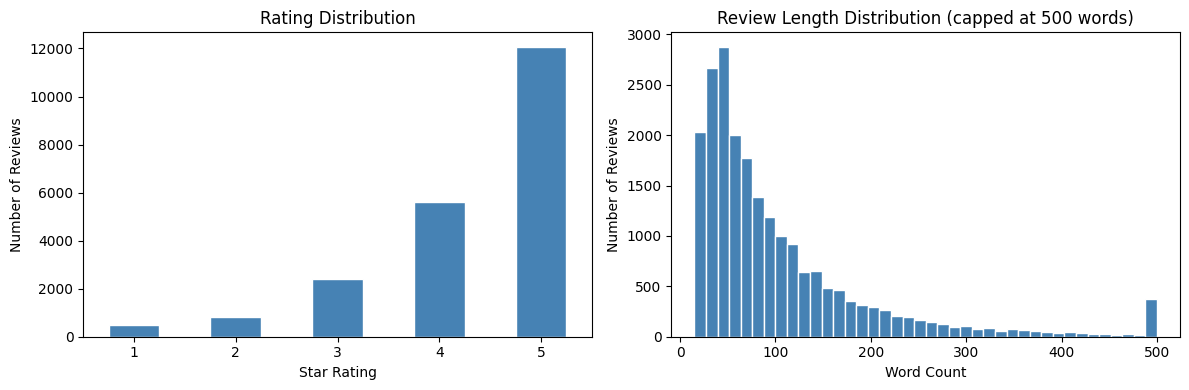

Plot saved to plots/01_data_overview.png


In [11]:
# ── Step 1d: Final dataset summary ────────────────────────────────────────────
import matplotlib.pyplot as plt

print(f'Final dataset size: {len(df)} reviews')
print(f"Average word count: {df['word_count'].mean():.1f} words")
print(f"\nRating distribution after cleaning:")
print(df['rating'].value_counts().sort_index())

# Plot rating distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=0)

df['word_count'].clip(upper=500).plot(kind='hist', bins=40, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Review Length Distribution (capped at 500 words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Number of Reviews')

plt.tight_layout()
# plt.savefig('plots/01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to plots/01_data_overview.png')

## Step 2: Word Embeddings

We train a Word2Vec model on the cleaned, tokenized reviews, then explore the embedding space to understand how the model represents product-related concepts.

In [12]:
# ── Step 2a: Train Word2Vec ────────────────────────────────────────────────────
# Word2Vec learns a 50-dimensional vector for each word by predicting
# neighbouring words in a sentence (Skip-Gram with window=5).
# min_count=3 drops words that appear fewer than 3 times (too rare to learn from).

from gensim.models import Word2Vec

sentences = df['review_tokens'].tolist()

model = Word2Vec(
    sentences=sentences,
    vector_size=50,   # embedding dimension d=50
    window=5,         # context window on each side
    min_count=5,      # ignore words seen fewer than 3 times
    workers=4,        # parallel training threads
    seed=42
)

vocab_size = len(model.wv)
print(f'Vocabulary size: {vocab_size} words')
print(f'Embedding shape: {model.wv.vectors.shape}')
print(f'\nSample vector for "camera" (first 10 dims):')
print(model.wv['camera'][:10])

Vocabulary size: 7818 words
Embedding shape: (7818, 50)

Sample vector for "camera" (first 10 dims):
[ 0.86081374 -0.5147428  -0.2810563   1.0984651  -0.49474493  0.17190701
 -0.5047607   0.9968397   0.76250833  0.64986235]


In [13]:
# ── Step 2b: Quality axis ("excellent" → "horrible") ─────────────────────────
# A "direction" in embedding space is just the vector difference between
# two opposite words. Words that project highly onto this axis share
# meaning with the positive end; low projections share meaning with the negative end.

import numpy as np

pos_word, neg_word = 'excellent', 'horrible'
quality_axis = model.wv[pos_word] - model.wv[neg_word]  # direction vector

# Project every word onto this axis
words = list(model.wv.index_to_key)
projections = {w: np.dot(model.wv[w], quality_axis) for w in words}

ranked = sorted(projections.items(), key=lambda x: x[1], reverse=True)

print(f'Quality axis: "{pos_word}" → "{neg_word}"\n')
print('Top 15 words (most positive / high quality):')
for w, score in ranked[:15]:
    print(f'  {w:20s} {score:+.3f}')

print('\nBottom 15 words (most negative / low quality):')
for w, score in ranked[-15:]:
    print(f'  {w:20s} {score:+.3f}')

Quality axis: "excellent" → "horrible"

Top 15 words (most positive / high quality):
  amazing              +34.012
  lion                 +32.686
  excellent            +32.472
  fantastic            +29.719
  king                 +29.359
  wonderful            +28.921
  loved                +28.303
  enjoyed              +27.637
  great                +27.285
  clean                +26.957
  shows                +26.484
  awesome              +26.482
  parades              +24.576
  recommend            +24.338
  spectacular          +24.292

Bottom 15 words (most negative / low quality):
  queue                -21.030
  parking              -21.222
  bags                 -21.283
  summer               -21.642
  crowds               -21.685
  gate                 -21.932
  hour                 -21.989
  sun                  -22.588
  stroller             -22.626
  strollers            -23.045
  heat                 -23.501
  bag                  -23.614
  people               -24.277

In [14]:
# ── Step 2c: Inspect one embedding dimension ──────────────────────────────────
# Each of the 50 dimensions is a learned feature. We can look at which words
# score highest/lowest on a single dimension to get a sense of what it captures.

DIM = 0  # change this to inspect other dimensions (0–49)

dim_scores = {w: model.wv[w][DIM] for w in words}
dim_ranked = sorted(dim_scores.items(), key=lambda x: x[1], reverse=True)

print(f'Dimension #{DIM}\n')
print('Highest-scoring words:')
for w, score in dim_ranked[:10]:
    print(f'  {w:20s} {score:+.4f}')

print('\nLowest-scoring words:')
for w, score in dim_ranked[-10:]:
    print(f'  {w:20s} {score:+.4f}')

Dimension #0

Highest-scoring words:
  years                +4.7672
  birthday             +3.8212
  year                 +2.9227
  prices               +2.8496
  times                +2.6582
  bring                +2.6553
  reviews              +2.5824
  school               +2.4494
  memories             +2.4381
  drinks               +2.4052

Lowest-scoring words:
  well                 -3.0848
  popular              -3.1077
  cast                 -3.1281
  recommend            -3.1459
  open                 -3.2113
  land                 -3.3440
  mystic               -3.4510
  walk                 -3.5536
  story                -3.6760
  toy                  -3.8211


In [15]:
# ── Step 2d: Analysis i — Nearest neighbours of brand-related words ───────────
# Words that are close in embedding space tend to appear in similar contexts.
# For brand words, this reveals what reviewers associate with each concept.

brand_words = ['disney', 'park', 'queue', 'ride', 'movie']

for word in brand_words:
    if word in model.wv:
        neighbors = model.wv.most_similar(word, topn=8)
        print(f'\nNearest neighbours of "{word}":')
        for neighbor, similarity in neighbors:
            print(f'  {neighbor:20s} cosine similarity: {similarity:.3f}')
    else:
        print(f'\n"{word}" not in vocabulary (too rare or filtered out)')


Nearest neighbours of "disney":
  disneyland           cosine similarity: 0.746
  dl                   cosine similarity: 0.556
  florida              cosine similarity: 0.550
  class                cosine similarity: 0.547
  orlando              cosine similarity: 0.533
  disneylands          cosine similarity: 0.532
  original             cosine similarity: 0.525
  compare              cosine similarity: 0.509

Nearest neighbours of "park":
  parks                cosine similarity: 0.824
  walkable             cosine similarity: 0.467
  everything           cosine similarity: 0.461
  relaxed              cosine similarity: 0.448
  enough               cosine similarity: 0.446
  easily               cosine similarity: 0.441
  disneyland           cosine similarity: 0.427
  resort               cosine similarity: 0.419

Nearest neighbours of "queue":
  que                  cosine similarity: 0.884
  q                    cosine similarity: 0.874
  queues               cosine similarity

In [16]:
# ── Step 2e: Analysis ii — Word analogies ─────────────────────────────────────
# Word2Vec captures analogical relationships via vector arithmetic.
# "camera – photo + audio = ?" asks: what is to audio what "camera" is to "photo"?
# We add the positive words and subtract the negative word, then find the nearest result.

analogies = [
     # (positive words, negative words, interpretation)
    (['ride', 'fun'], ['queue'],   '"ride – queue + fun" → fun part of rides without waiting'),
    (['staff', 'helpful'], ['rude'], '"staff – rude + helpful" → positive staff experience'),
    (['food', 'expensive'], ['cheap'], '"food – cheap + expensive" → expensive food experience'),
    (['park', 'clean'], ['dirty'], '"park – dirty + clean" → clean park atmosphere'),
    (['disney', 'magic'], ['crowd'], '"disney – crowd + magic" → magical Disney experience without crowds'),

]


for positives, negatives, label in analogies:
    # Check all words exist in vocab before querying
    all_words = positives + negatives
    missing = [w for w in all_words if w not in model.wv]
    if missing:
        print(f'\n{label}')
        print(f'  Skipped — not in vocabulary: {missing}')
        continue
    results = model.wv.most_similar(positive=positives, negative=negatives, topn=5)
    print(f'\n{label}')
    for word, score in results:
        print(f'  {word:20s} {score:.3f}')


"ride – queue + fun" → fun part of rides without waiting
  exciting             0.639
  loved                0.634
  enjoyed              0.598
  liked                0.598
  grizzly              0.517

"staff – rude + helpful" → positive staff experience
  professional         0.675
  clean                0.639
  organised            0.613
  casts                0.595
  crew                 0.590

"food – cheap + expensive" → expensive food experience
  foods                0.616
  average              0.595
  selection            0.590
  decent               0.588
  mediocre             0.586

"park – dirty + clean" → clean park atmosphere
  parks                0.615
  explore              0.554
  day                  0.537
  everything           0.534
  easily               0.530

"disney – crowd + magic" → magical Disney experience without crowds
  history              0.649
  walt                 0.622
  original             0.612
  created              0.604
  nostalgic        

## Step 3: Topic Modelling + Sentiment Analysis

We split each review into sentences, run BERTopic to discover recurring themes, then use VADER sentiment analysis to score each sentence. Finally, we compare topic prevalence and sentiment between low-rated (1–3★) and high-rated (4–5★) reviews.

In [17]:
# Install Step 3 dependencies (uncomment if needed)
!pip install bertopic sentence-transformers vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 11.8 MB/s eta 0:00:00


In [18]:
# ── Step 3a: Split reviews into sentences ─────────────────────────────────────
# BERTopic works best on short, focused text — sentences rather than full reviews.
# We keep each sentence's metadata (review_id, rating, star_group) for later aggregation.

from nltk.tokenize import sent_tokenize

df['star_group'] = df['rating'].apply(lambda r: 'low (1-3★)' if r <= 3 else 'high (4-5★)')

sentences_data = []
for idx, row in df.iterrows():
    for sent in sent_tokenize(row['review_clean']):
        if len(sent.split()) >= 5:   # skip fragments
            sentences_data.append({
                'review_id': idx,
                'rating':    row['rating'],
                'star_group': row['star_group'],
                'sentence':  sent
            })

sdf = pd.DataFrame(sentences_data)
print(f'Total sentences: {len(sdf)}')
print(f'\nSample:')
print(sdf['sentence'].head(3).tolist())

Total sentences: 129605

Sample:
["If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street!", 'It has a very familiar feel.', 'One of the rides its a Small World is absolutely fabulous and worth doing.']


In [ ]:
#DON'T RUN THIS ONE BELOW
# ── Step 3b: Run BERTopic ──────────────────────────────────────────────────────
# BERTopic embeds sentences with a transformer, clusters them with HDBSCAN,
# and labels each cluster with the most representative words.
#
# Strategy: fit on a 25k random sample (fast), then predict on all sentences.
# This gives the same topic definitions without the cost of embedding all sentences twice.
#
# CountVectorizer removes stopwords from topic labels (e.g. 'the', 'and', 'it').
#
# ⏱ Expect ~15–20 minutes on CPU.

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

sample = sdf.sample(n=25000, random_state=42)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=CountVectorizer(stop_words='english'),
    nr_topics=15,
    min_topic_size=200,
    verbose=True
)
topic_model.fit(sample['sentence'].tolist())

# Predict topics for all sentences
topics, _ = topic_model.transform(sdf['sentence'].tolist())
sdf['topic'] = topics

# Show discovered topics
topic_info = topic_model.get_topic_info()
print('\nDiscovered topics:')
for _, row in topic_info.iterrows():
    top_words = [w for w, _ in topic_model.get_topic(row['Topic'])][:6] if row['Topic'] != -1 else ['(outlier sentences)']
    print(f"  Topic {row['Topic']:3d} | {row['Count']:5d} sentences | {', '.join(top_words)}")

In [20]:
import os
os.makedirs('models', exist_ok=True)
sdf.to_pickle('models/sdf_topics.pkl')
topic_model.save('models/bertopic_model', serialization='pickle')
print('Saved!')

NameError: name 'topic_model' is not defined

In [19]:
# ── Save BERTopic results to Google Drive (run once after Step 3b) ────────────
# After this, share the Drive folder with your group.
# They use the Load cell below instead of rerunning BERTopic.

from google.colab import drive
drive.mount('/content/drive')

import os
save_path = '/content/drive/MyDrive/assignment1_models'
os.makedirs(save_path, exist_ok=True)

sdf.to_pickle(f'{save_path}/disney_sdf_topics.pkl')
topic_model.save(f'{save_path}/disney_bertopic_model', serialization='pickle')
print(f'Saved to Google Drive: {save_path}')




Mounted at /content/drive


FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/assignment1_models'

In [32]:
import subprocess
result = subprocess.run(['find', '/content/drive', '-name', 'disney_sdf_topics.pkl'],
                      capture_output=True, text=True)
print(result.stdout)

#RUN THIS FOR STEP 3B
# ── Load BERTopic results from Google Drive (everyone else runs this) ─────────
# Skip the training cell entirely and run this instead.

from google.colab import drive
drive.mount('/content/drive')

from bertopic import BERTopic
import warnings
warnings.filterwarnings('ignore')

save_path = '/content/drive/.shortcut-targets-by-id/1aJGiyzKMwnYatXyDxJaUxo0D1s4kN_qa/assignment1_models'
sdf = pd.read_pickle(f'{save_path}/disney_sdf_topics.pkl')
topic_model = BERTopic.load(f'{save_path}/disney_bertopic_model')
print('Loaded from Google Drive!')

topic_info = topic_model.get_topic_info()
print('\nTopics:')
for _, row in topic_info.iterrows():
    words = [w for w, _ in topic_model.get_topic(row['Topic'])][:6] if row['Topic'] != -1 else ['(outliers)']
    print(f"  Topic {row['Topic']:3d} | {row['Count']:5d} sentences | {', '.join(words)}")

/content/drive/.shortcut-targets-by-id/1aJGiyzKMwnYatXyDxJaUxo0D1s4kN_qa/assignment1_models/disney_sdf_topics.pkl

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded from Google Drive!

Topics:
  Topic  -1 |  1608 sentences | (outliers)
  Topic   0 | 15884 sentences | rides, park, time, day, ride, food
  Topic   1 |   504 sentences | hong, kong, hk, disneyland, disney, visit
  Topic   2 |  1475 sentences | fireworks, parade, castle, parades, night, day
  Topic   3 |   224 sentences | characters, meet, character, photos, photo, autograph
  Topic   4 |  5305 sentences | disney, disneyland, park, paris, time, world


In [27]:
from bertopic import BERTopic
import warnings
warnings.filterwarnings('ignore')

sdf = pd.read_pickle('models/sdf_topics.pkl')
topic_model = BERTopic.load('models/bertopic_model')

print('Loaded sdf and topic_model from disk.')
topic_info = topic_model.get_topic_info()
print('\nTopics:')
for _, row in topic_info.iterrows():
    top_words = [w for w, _ in topic_model.get_topic(row['Topic'])][:6] if row['Topic'] != -1 else ['(outlier sentences)']
    print(f"  Topic {row['Topic']:3d} | {row['Count']:5d} sentences | {', '.join(top_words)}")

RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-69ccf050-0353cfc57dd5858b387f28ae;ed23389c-abf3-4f29-9d23-0e5983f98138)

Repository Not Found for url: https://huggingface.co/models/bertopic_model/resolve/main/topics.json.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

In [34]:
# ── Step 3c: Manually label topics ────────────────────────────────────────────
# After inspecting the top words above, assign a human-readable label to each topic.
# Topic -1 is BERTopic's "outlier" bucket — sentences that didn't fit any cluster.
# Update this dictionary based on what you see in the output above.

TOPIC_LABELS = {
    -1: 'Outlier',
     0: 'Rides & Park Experience',
     1: 'Hong Kong Disneyland',
     2: 'Fireworks & Parades',
     3: 'Characters & Meet & Greet',
     4: 'Paris Disneyland',
}
sdf['topic_label'] = sdf['topic'].map(TOPIC_LABELS).fillna('Other')

print('Topic label distribution:')
print(sdf['topic_label'].value_counts().to_string())

Topic label distribution:
topic_label
Rides & Park Experience      178615
Paris Disneyland              60706
Outlier                       20707
Fireworks & Parades           16135
Hong Kong Disneyland           5556
Characters & Meet & Greet      2198


In [35]:
# ── Step 3d: Sentiment analysis with VADER ────────────────────────────────────
# VADER is a rule-based sentiment analyser tuned for short social/review text.
# The compound score ranges from -1 (very negative) to +1 (very positive).

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

sdf['sentiment'] = sdf['sentence'].apply(
    lambda s: analyzer.polarity_scores(s)['compound']
)

print('Sentiment score distribution:')
print(sdf['sentiment'].describe().round(3))
print(f"\nPositive sentences (>0.05):  {(sdf['sentiment'] >  0.05).sum()}")
print(f"Neutral  sentences (-0.05–0.05): {((sdf['sentiment'] >= -0.05) & (sdf['sentiment'] <= 0.05)).sum()}")
print(f"Negative sentences (<-0.05): {(sdf['sentiment'] < -0.05).sum()}")

Sentiment score distribution:
count    283917.000
mean          0.240
std           0.409
min          -0.986
25%           0.000
50%           0.226
75%           0.598
max           1.000
Name: sentiment, dtype: float64

Positive sentences (>0.05):  153810
Neutral  sentences (-0.05–0.05): 86484
Negative sentences (<-0.05): 43623


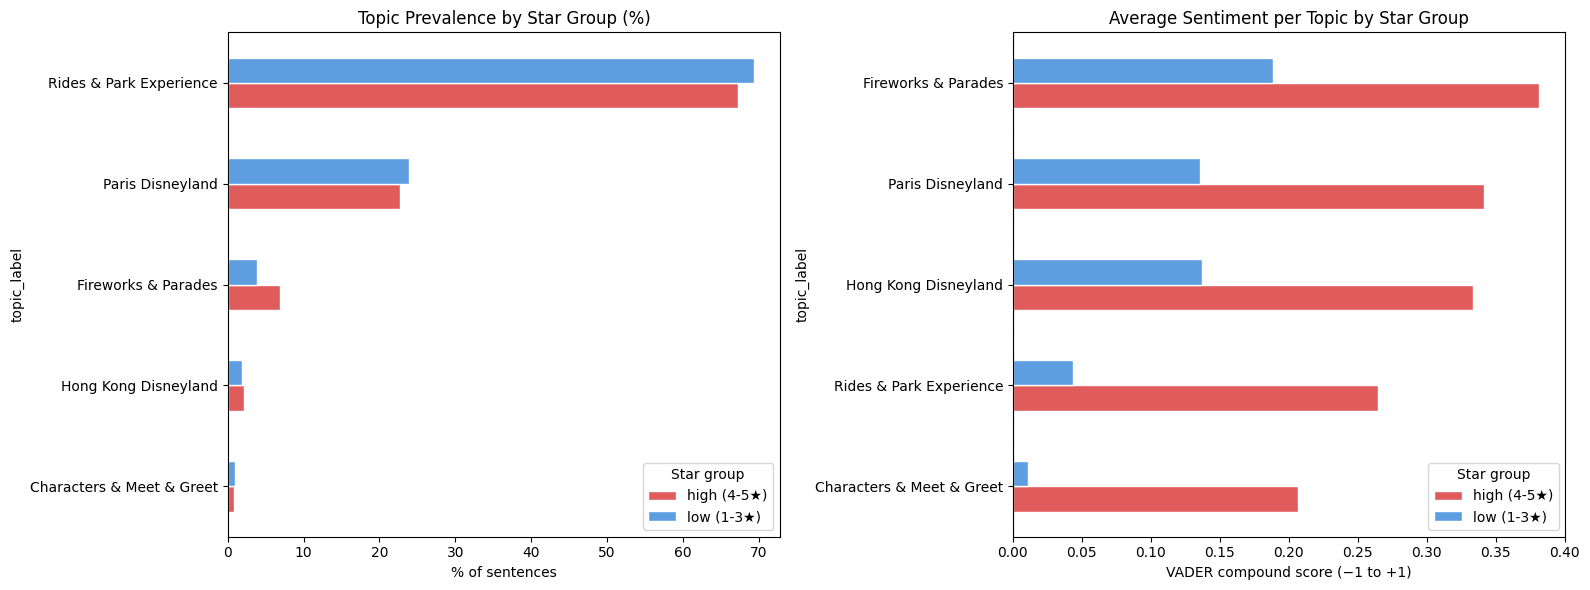

Plot saved to plots/03_topic_sentiment.png

Sentiment by topic and star group:
star_group                 high (4-5★)  low (1-3★)
topic_label                                       
Characters & Meet & Greet        0.207       0.011
Fireworks & Parades              0.382       0.188
Hong Kong Disneyland             0.333       0.137
Paris Disneyland                 0.341       0.136
Rides & Park Experience          0.265       0.044


In [36]:
# ── Step 3e: Comparative analysis — low vs high star reviews ──────────────────
# For each topic, compare:
#   1. Prevalence: what share of sentences in low/high reviews belong to this topic?
#   2. Sentiment: what is the average sentiment per topic in each group?

import matplotlib.pyplot as plt

# Exclude outliers from the comparison
sdf_clean = sdf[sdf['topic'] != -1].copy()

# ── Prevalence ────────────────────────────────────────────────────────────────
prevalence = (
    sdf_clean.groupby(['star_group', 'topic_label'])
    .size()
    .reset_index(name='count')
)
prevalence['pct'] = prevalence.groupby('star_group')['count'].transform(lambda x: x / x.sum() * 100)

prev_pivot = prevalence.pivot(index='topic_label', columns='star_group', values='pct').fillna(0)

# ── Sentiment ─────────────────────────────────────────────────────────────────
sent_pivot = (
    sdf_clean.groupby(['star_group', 'topic_label'])['sentiment']
    .mean()
    .unstack('star_group')
    .fillna(0)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

prev_pivot.sort_values('high (4-5★)', ascending=True).plot(
    kind='barh', ax=axes[0], color=['#e05c5c', '#5c9ee0'], edgecolor='white'
)
axes[0].set_title('Topic Prevalence by Star Group (%)')
axes[0].set_xlabel('% of sentences')
axes[0].legend(title='Star group')

sent_pivot.sort_values('high (4-5★)', ascending=True).plot(
    kind='barh', ax=axes[1], color=['#e05c5c', '#5c9ee0'], edgecolor='white'
)
axes[1].set_title('Average Sentiment per Topic by Star Group')
axes[1].set_xlabel('VADER compound score (−1 to +1)')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].legend(title='Star group')

plt.tight_layout()
# plt.savefig('plots/03_topic_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to plots/03_topic_sentiment.png')

# Print summary table
print('\nSentiment by topic and star group:')
print(sent_pivot.round(3).to_string())

Part 4: Drivers of Rating

In [37]:
# ── Build feature matrix per review ───────────────────────────────────────────
# Three types of predictors (all standardized later):
#   sentiment_overall : mean VADER score across all sentences in the review
#   share_<topic>     : fraction of sentences assigned to each topic
#   sent_<topic>      : mean sentiment of sentences about each topic (0 if none)

import pandas as pd
import numpy as np

def slugify(s):
    return str(s).replace(' & ', '').replace(' ', '').replace('/', '_')

# Use topic_label if it exists, otherwise fall back to numeric topic id
label_col = 'topic_label' if 'topic_label' in sdf.columns else 'topic'

# i) Overall sentiment per review
sent_overall = sdf.groupby('review_id')['sentiment'].mean().rename('sentiment_overall')

# ii) Topic share per review (exclude outlier topic -1)
sdf_topics = sdf[sdf['topic'] != -1].copy()
topic_counts = sdf_topics.groupby(['review_id', label_col]).size().unstack(fill_value=0)
topic_shares = topic_counts.div(topic_counts.sum(axis=1), axis=0)
topic_shares.columns = [f'share_{slugify(c)}' for c in topic_shares.columns]

# iii) Topic-level sentiment per review
topic_sent = sdf_topics.groupby(['review_id', label_col])['sentiment'].mean().unstack(fill_value=0)
topic_sent.columns = [f'sent_{slugify(c)}' for c in topic_sent.columns]

# Merge with rating
features = df[['rating']].join(sent_overall).join(topic_shares).join(topic_sent)
features = features.dropna()

print(f'Feature matrix: {features.shape[0]} reviews x {features.shape[1]} columns')
print(f'  1 overall sentiment + {len([c for c in features.columns if c.startswith("share_")])} topic shares + {len([c for c in features.columns if c.startswith("sent_")])} topic sentiments')

Feature matrix: 21343 reviews x 12 columns
  1 overall sentiment + 5 topic shares + 5 topic sentiments


In [38]:
# ── OLS regression ─────────────────────────────────────────────────────────────
# All predictors standardized to mean=0, unit variance so coefficients
# are directly comparable across variables.

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

y = features['rating']
X_raw = features.drop(columns=['rating'])

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index
)
X_scaled = sm.add_constant(X_scaled)

ols = sm.OLS(y, X_scaled).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     465.9
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:26:56   Log-Likelihood:                -27593.
No. Observations:               21343   AIC:                         5.521e+04
Df Residuals:                   21332   BIC:                         5.530e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

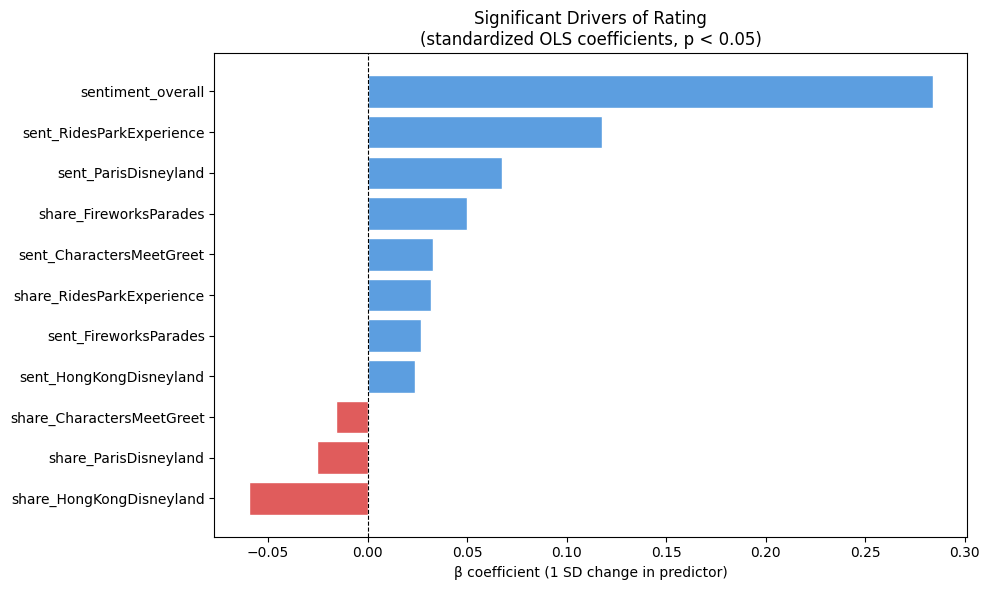

Saved: plots/05_regression_drivers.png


In [39]:
# ── Plot significant drivers ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import os
os.makedirs('plots', exist_ok=True)

coef = ols.params.drop('const')
pval = ols.pvalues.drop('const')
sig  = coef[pval < 0.05].sort_values()

colors = ['#e05c5c' if v < 0 else '#5c9ee0' for v in sig.values]

fig, ax = plt.subplots(figsize=(10, max(6, len(sig) * 0.35)))
ax.barh(sig.index, sig.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Significant Drivers of Rating\n(standardized OLS coefficients, p < 0.05)')
ax.set_xlabel('β coefficient (1 SD change in predictor)')
plt.tight_layout()
plt.savefig('plots/05_regression_drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/05_regression_drivers.png')

In [40]:
# ── Answer the three assignment questions ─────────────────────────────────────
print('='*65)
print('i) OVERALL IMPACT OF REVIEWER SENTIMENT')
print('='*65)
b = ols.params['sentiment_overall']
p = ols.pvalues['sentiment_overall']
print(f'  sentiment_overall: β = {b:.3f}, p = {p:.4f}')
print(f'  A 1 SD increase in overall sentiment → {b:+.3f} change in rating')

print()
print('='*65)
print('ii) TOPICS WHERE SENTIMENT HAS THE STRONGEST IMPACT ON RATING')
print('='*65)
sent_coefs = ols.params[[c for c in ols.params.index if c.startswith('sent_')]]
sent_pvals = ols.pvalues[[c for c in ols.pvalues.index if c.startswith('sent_')]]
sent_sig = sent_coefs[sent_pvals < 0.05].reindex(
    sent_coefs[sent_pvals < 0.05].abs().sort_values(ascending=False).index
)
if len(sent_sig) == 0:
    print('  No significant topic-sentiment predictors found.')
for var, val in sent_sig.items():
    print(f'  {var:45s} β = {val:+.3f}  (p = {sent_pvals[var]:.4f})')

print()
print('='*65)
print('iii) TOPICS THAT DIRECTLY IMPACT THE DV (topic share)')
print('='*65)
share_coefs = ols.params[[c for c in ols.params.index if c.startswith('share_')]]
share_pvals = ols.pvalues[[c for c in ols.pvalues.index if c.startswith('share_')]]
share_sig = share_coefs[share_pvals < 0.05].sort_values(ascending=False)
if len(share_sig) == 0:
    print('  No significant topic-share predictors found.')
for var, val in share_sig.items():
    print(f'  {var:45s} β = {val:+.3f}  (p = {share_pvals[var]:.4f})')

print()
print(f'Model R² = {ols.rsquared:.3f}, Adj. R² = {ols.rsquared_adj:.3f}, N = {int(ols.nobs)}')

i) OVERALL IMPACT OF REVIEWER SENTIMENT
  sentiment_overall: β = 0.284, p = 0.0000
  A 1 SD increase in overall sentiment → +0.284 change in rating

ii) TOPICS WHERE SENTIMENT HAS THE STRONGEST IMPACT ON RATING
  sent_RidesParkExperience                      β = +0.118  (p = 0.0000)
  sent_ParisDisneyland                          β = +0.068  (p = 0.0000)
  sent_CharactersMeetGreet                      β = +0.033  (p = 0.0000)
  sent_FireworksParades                         β = +0.027  (p = 0.0002)
  sent_HongKongDisneyland                       β = +0.024  (p = 0.0016)

iii) TOPICS THAT DIRECTLY IMPACT THE DV (topic share)
  share_FireworksParades                        β = +0.050  (p = 0.0000)
  share_RidesParkExperience                     β = +0.032  (p = 0.0000)
  share_CharactersMeetGreet                     β = -0.016  (p = 0.0151)
  share_ParisDisneyland                         β = -0.025  (p = 0.0000)
  share_HongKongDisneyland                      β = -0.060  (p = 0.0000)

Mod